In [1]:
#自动重载外部文件的更新
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","机器学习实践/聚类")
sys.path.append(currentPath)

# 要求
配对交易策略聚类分析(sp500data.xlsx) (行是日期，列是股票名称）
1.删除掉所有空缺值占比超过30%的股票
2.使用k-means, k-medoids, dbscan, agens 方法股票交易配对，并对聚类结果进行比较，分析其中的原因
提示：按月收益和月风险(月收益均值和月收益标准差）聚类

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import pandas as pd

datadir = r"D:\PythonEx\machinelearningIntro\data\SP500Data.csv"

In [14]:
raw_df = pd.read_csv(datadir)

In [15]:
raw_df.head()

,Date,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
0,2018-01-02,58.790001,98.410004,192.490005,153.839996,64.309998,177.699997,10.98,106.089996,10.88,...,146.990005,164.300003,47.810001,29.370001,67.879997,68.070000,81.599998,124.059998,50.700001,71.769997
1,2018-01-03,58.919998,99.949997,195.820007,154.550003,65.309998,181.039993,11.55,107.050003,10.87,...,149.740005,162.520004,47.490002,29.330000,69.239998,68.900002,81.529999,124.919998,50.639999,72.099998
2,2018-01-04,58.820000,99.379997,199.250000,156.380005,64.660004,183.220001,12.12,111.000000,10.83,...,151.259995,163.399994,47.119999,29.690001,70.489998,69.360001,82.360001,124.739998,50.849998,72.529999
3,2018-01-05,58.990002,101.110001,202.320007,157.669998,66.370003,185.339996,11.88,112.180000,10.87,...,152.229996,164.490005,46.790001,29.910000,74.150002,69.230003,82.839996,125.980003,50.869999,73.360001
4,2018-01-08,58.820000,99.489998,207.800003,158.929993,66.629997,185.039993,12.28,111.389999,10.87,...,151.410004,162.300003,47.139999,30.260000,74.639999,69.480003,82.980003,126.220001,50.619999,74.239998


In [16]:
df_na_sum = raw_df.apply(lambda col:col.isna().sum(),axis=0)
df_na_sum = pd.DataFrame(df_na_sum)
df_na_sum.columns = ["空值数量"]
df_na_sum['占比'] = df_na_sum["空值数量"]/len(raw_df)
df_na_sum

,空值数量,占比
Date,0,0.0
ABT,0,0.0
ABBV,0,0.0
ABMD,0,0.0
ACN,0,0.0
...,...,...
XYL,0,0.0
YUM,0,0.0
ZBH,0,0.0
ZION,0,0.0


In [17]:
raw_df.shape

(448, 503)

# 数据清洗，删去空缺值占比较大的样本

In [18]:
df = raw_df.dropna(thresh=(1-0.3)*len(raw_df),axis=1)
df.shape

(448, 499)

In [19]:
df.describe()


,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
count,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,...,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000,448.000000
mean,70.934196,88.078013,307.303839,167.473750,59.630804,252.270603,21.804754,147.501428,14.534888,128.423750,...,165.139486,139.475335,51.671027,29.151071,90.774487,74.549040,93.492455,120.406161,49.230245,94.787232
std,9.015754,13.480891,71.989893,14.635497,13.119012,29.001055,7.425020,21.095302,2.266254,38.573308,...,17.383970,29.251895,6.650626,3.450413,21.081242,4.926937,11.958700,9.199975,4.820335,14.395919
min,56.270000,62.980000,159.309998,133.669998,40.110001,177.699997,9.530000,103.760002,10.060000,71.800003,...,134.839996,92.010002,42.130001,18.920000,62.820000,61.380001,76.300003,97.230003,38.509998,71.510002
25%,62.620001,78.657503,260.557487,157.280006,47.037500,235.377495,15.147500,133.307499,12.847500,94.059998,...,151.705002,114.085001,45.689999,27.139999,71.664999,70.547503,83.507502,114.030001,45.107500,84.557499
50%,70.014999,88.524998,301.940002,162.880005,55.269999,254.684998,21.885000,154.949997,14.830000,113.389999,...,158.809998,132.974998,49.370001,29.075000,85.195000,75.165001,89.930000,120.645000,49.184999,90.090000
75%,78.620003,96.667498,368.095001,178.337502,71.565002,272.989990,28.437500,163.614998,16.355000,158.855000,...,178.064999,164.927498,56.715001,31.455000,109.367500,78.359999,101.462500,125.850002,53.214999,101.970001
max,88.739998,123.209999,449.750000,201.119995,83.389999,311.269989,34.389999,184.720001,18.410000,215.759995,...,199.360001,201.509995,65.820000,36.480000,139.720001,84.410004,119.209999,142.610001,58.540001,128.470001


In [20]:
df["Date"] = pd.to_datetime(df["Date"], format='%Y-%m-%d', errors='coerce')
df["Date"].describe(datetime_is_numeric=True)

C:\Users\serendipity\AppData\Local\Temp\ipykernel_9496\243649196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"], format='%Y-%m-%d', errors='coerce')


count                              448
mean     2018-11-22 00:22:29.999999744
min                2018-01-02 00:00:00
25%                2018-06-12 18:00:00
50%                2018-11-19 12:00:00
75%                2019-05-03 18:00:00
max                2019-10-11 00:00:00
Name: Date, dtype: object

## 数据准备-失败的格式转换（维度没转换成功）

In [60]:
data = df.groupby([df["Date"].dt.year,df["Date"].dt.month]).agg(["mean","std"]).copy()
data

C:\Users\serendipity\AppData\Local\Temp\ipykernel_11064\2301743927.py:1: FutureWarning: ['Date'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  data = df.groupby([df["Date"].dt.year,df["Date"].dt.month]).agg(["mean","std"]).copy()


ABT                  ABBV                  ABMD             \
                mean       std        mean       std        mean        std   
Date Date                                                                     
2018 1     60.036191  1.782727  105.356190  7.322083  219.550476  14.852734   
     2     59.199473  1.511837  114.937896  3.593433  252.970001  16.397485   
     3     61.427143  1.537612  109.745238  9.671253  287.715238   7.731552   
     4     58.946667  0.652628   93.043334  2.235835  296.008096   8.542088   
     5     60.627727  1.489988  102.738182  2.574329  368.242730  26.190863   
     6     62.300953  0.939414   96.963811  3.052991  422.311428  15.919023   
     7     63.324286  1.521617   93.731429  2.741020  407.449047  23.185363   
     8     65.178260  1.155368   96.610870  1.401118  376.931737  13.451765   
     9     68.814211  2.524786   93.892105  1.277397  400.466315  26.350424   
     10    69.620869  2.115882   88.630435  5.949176  378.187395  34.223702   
     11    70.812857  1.719248   87.322381  3.539699  344.032382  40.365393   
     12    70.484210  2.005316   87.786317  3.006651  313.747371  17.274439   
2019 1     69.829524  1.504671   85.717619  4.268331  329.152857  13.364608   
     2     74.736842  1.654003   79.854210  0.688213  349.829473  10.070751   
     3     78.674763  0.987070   79.668095  1.096583  319.732858  20.532226   
     4     77.696190  1.935414   80.779047  2.014427  273.165716   9.664913   
     5     76.663181  1.113713   78.799545  1.314680  263.023641   5.965453   
     6     82.049000  2.548504   76.091999  3.864028  259.619996   6.370982   
     7     86.319090  1.753663   69.742728  2.552354  264.989997   7.476911   
     8     84.697274  1.170393   65.511363  1.128595  194.081362   4.633756   
     9     83.783500  1.072622   70.610999  2.936543  186.736500   5.055037   
     10    80.361110  1.185647   73.678889  0.772908  165.010000   4.236524   

                  ACN                  ATVI            ...        XYL  \
                 mean        std       mean       std  ...       mean   
Date Date                                              ...              
2018 1     159.411905   2.267410  69.228572  2.820713  ...  71.084287   
     2     158.534210   4.084419  70.237895  2.176343  ...  73.831053   
     3     157.321429   5.222652  72.278096  3.487372  ...  76.893809   
     4     151.089047   2.235505  66.264285  1.042385  ...  76.617619   
     5     154.486818   1.824349  70.619545  1.441102  ...  71.387273   
     6     161.078571   2.607829  75.430952  1.619229  ...  69.884762   
     7     165.264287   2.551552  78.121429  2.570049  ...  68.661905   
     8     163.559565   3.291177  71.513913  1.891196  ...  75.726522   
     9     171.286844   1.744538  78.627895  3.712423  ...  79.986316   
     10    161.712172   7.238425  74.410435  5.660135  ...  71.728695   
     11    160.955714   2.741106  55.559523  6.923371  ...  69.702380   
     12    150.923158  10.073055  47.038947  1.064638  ...  65.525263   
2019 1     147.325237   4.697119  47.533810  1.557143  ...  68.745714   
     2     158.360001   2.338838  43.474210  2.034050  ...  72.950527   
     3     165.803811   3.685258  44.420000  2.080192  ...  77.213810   
     4     178.798572   1.764024  46.916190  1.048668  ...  81.729524   
     5     177.066365   2.609745  45.296818  2.174058  ...  76.875455   
     6     183.242499   2.865677  45.587500  1.248097  ...  80.613500   
     7     193.400001   2.666930  47.168637  1.028158  ...  81.705910   
     8     193.151362   3.615989  48.352273  1.699115  ...  75.943636   
     9     194.038500   2.974923  54.491000  1.251928  ...  78.011000   
     10    185.785555   2.522900  54.015555  1.086693  ...  75.462223   

                            YUM                   ZBH                 ZION  \
                std        mean       std        mean       std       mean   
Date Date                                                  

In [61]:
data1 = data.copy()
data1.index.names = ["year", "month"]
data1 = data1.reset_index()

In [62]:
data1.columns = ['_'.join(col) for col in data1.columns]
data1

,year_,month_,ABT_mean,ABT_std,ABBV_mean,ABBV_std,ABMD_mean,ABMD_std,ACN_mean,ACN_std,...,XYL_mean,XYL_std,YUM_mean,YUM_std,ZBH_mean,ZBH_std,ZION_mean,ZION_std,ZTS_mean,ZTS_std
0,2018,1,60.036191,1.782727,105.356190,7.322083,219.550476,14.852734,159.411905,2.267410,...,71.084287,1.812997,83.770000,1.498379,124.477143,1.761486,52.776190,1.320422,75.964762,2.424963
1,2018,2,59.199473,1.511837,114.937896,3.593433,252.970001,16.397485,158.534210,4.084419,...,73.831053,1.893797,79.463684,1.867468,119.509474,3.394345,54.014211,1.699070,77.303684,3.922113
2,2018,3,61.427143,1.537612,109.745238,9.671253,287.715238,7.731552,157.321429,5.222652,...,76.893809,1.807795,82.446665,1.334426,114.850000,4.306321,54.678095,1.685001,82.916667,1.505939
3,2018,4,58.946667,0.652628,93.043334,2.235835,296.008096,8.542088,151.089047,2.235505,...,76.617619,1.772419,85.723810,0.971723,109.123809,3.319785,53.237619,1.365697,83.864286,1.421111
4,2018,5,60.627727,1.489988,102.738182,2.574329,368.242730,26.190863,154.486818,1.824349,...,71.387273,1.211694,83.094091,1.300801,114.338182,2.381867,56.746818,1.370928,83.239544,1.418746
5,2018,6,62.300953,0.939414,96.963811,3.052991,422.311428,15.919023,161.078571,2.607829,...,69.884762,2.608551,81.493810,1.962726,112.734762,1.367683,55.511428,1.307904,86.214762,1.554115
6,2018,7,63.324286,1.521617,93.731429,2.741020,407.449047,23.185363,165.264287,2.551552,...,68.661905,2.099570,78.798095,0.504010,115.515238,4.670724,52.660000,0.775345,85.541428,0.951527
7,2018,8,65.178260,1.155368,96.610870,1.401118,376.931737,13.451765,163.559565,3.291177,...,75.726522,0.766336,83.355217,1.776449,124.369130,1.256326,53.439565,0.412547,90.883913,1.561681
8,2018,9,68.814211,2.524786,93.892105,1.277397,400.466315,26.350424,171.286844,1.744538,...,79.986316,1.511534,88.685790,1.074747,127.850527,3.544573,52.183684,1.042231,89.594211,0.872150
9,2018,10,69.620869,2.115882,88.630435,5.949176,378.187395,34.223702,161.712172,7.238425,...,71.728695,5.443553,88.937826,1.723058,123.915218,5.149010,48.532174,2.008162,90.865653,1.582561


In [68]:
data2 = data.copy()

In [69]:
data2 = data2.T
data2

Date             2018                                                  \
Date               1           2           3           4           5    
ABT  mean   60.036191   59.199473   61.427143   58.946667   60.627727   
     std     1.782727    1.511837    1.537612    0.652628    1.489988   
ABBV mean  105.356190  114.937896  109.745238   93.043334  102.738182   
     std     7.322083    3.593433    9.671253    2.235835    2.574329   
ABMD mean  219.550476  252.970001  287.715238  296.008096  368.242730   
...               ...         ...         ...         ...         ...   
ZBH  std     1.761486    3.394345    4.306321    3.319785    2.381867   
ZION mean   52.776190   54.014211   54.678095   53.237619   56.746818   
     std     1.320422    1.699070    1.685001    1.365697    1.370928   
ZTS  mean   75.964762   77.303684   82.916667   83.864286   83.239544   
     std     2.424963    3.922113    1.505939    1.421111    1.418746   

Date                                                                   ...  \
Date               6           7           8           9           10  ...   
ABT  mean   62.300953   63.324286   65.178260   68.814211   69.620869  ...   
     std     0.939414    1.521617    1.155368    2.524786    2.115882  ...   
ABBV mean   96.963811   93.731429   96.610870   93.892105   88.630435  ...   
     std     3.052991    2.741020    1.401118    1.277397    5.949176  ...   
ABMD mean  422.311428  407.449047  376.931737  400.466315  378.187395  ...   
...               ...         ...         ...         ...         ...  ...   
ZBH  std     1.367683    4.670724    1.256326    3.544573    5.149010  ...   
ZION mean   55.511428   52.660000   53.439565   52.183684   48.532174  ...   
     std     1.307904    0.775345    0.412547    1.042231    2.008162  ...   
ZTS  mean   86.214762   85.541428   90.883913   89.594211   90.865653  ...   
     std     1.554115    0.951527    1.561681    0.872150    1.582561  ...   

Date             2019                                                  \
Date               1           2           3           4           5    
ABT  mean   69.829524   74.736842   78.674763   77.696190   76.663181   
     std     1.504671    1.654003    0.987070    1.935414    1.113713   
ABBV mean   85.717619   79.854210   79.668095   80.779047   78.799545   
     std     4.268331    0.688213    1.096583    2.014427    1.314680   
ABMD mean  329.152857  349.829473  319.732858  273.165716  263.023641   
...               ...         ...         ...         ...         ...   
ZBH  std     2.200383    2.669962    2.310548    3.065534    4.212069   
ZION mean   45.518095   49.947895   47.868095   47.859048   46.450000   
     std     2.498010    0.978948    2.388453    0.826528    2.072849   
ZTS  mean   84.647619   90.844738   96.901905  101.260001  102.178637   
     std     1.175287    3.682444    2.232465    1.241700    0.747843   

Date                                                                   
Date               6           7           8           9           10  
ABT  mean   82.049000   86.319090   84.697274   83.783500   80.361110  
     std     2.548504    1.753663    1.170393    1.072622    1.185647  
ABBV mean   76.091999   69.742728   65.511363   70.610999   73.678889  
     std     3.864028    2.552354    1.128595    2.936543    0.772908  
ABMD mean  259.619996  264.989997  194.081362  186.736500  165.010000  
...               ...         ...         ...         ...         ...  
ZBH  std     2.069807    5.972836    1.735214    1.977784    1.527644  
ZION mean   44.378000   45.230455   40.924546   43.531500   42.943333  
     std     0.569373    0.864663    0.979993    1.696912    0.616645  
ZTS  mean  111.155500  114.560909  123.446818  124.443999  125.833334  
     std     2.546892    0.873526    3.980690    2.510606    1.837547  

[996 rows x 22 columns]

In [70]:
data2.index.names = ["stock_name", "agg"]
data2

Date                   2018                                                  \
Date                     1           2           3           4           5    
stock_name agg                                                                
ABT        mean   60.036191   59.199473   61.427143   58.946667   60.627727   
           std     1.782727    1.511837    1.537612    0.652628    1.489988   
ABBV       mean  105.356190  114.937896  109.745238   93.043334  102.738182   
           std     7.322083    3.593433    9.671253    2.235835    2.574329   
ABMD       mean  219.550476  252.970001  287.715238  296.008096  368.242730   
...                     ...         ...         ...         ...         ...   
ZBH        std     1.761486    3.394345    4.306321    3.319785    2.381867   
ZION       mean   52.776190   54.014211   54.678095   53.237619   56.746818   
           std     1.320422    1.699070    1.685001    1.365697    1.370928   
ZTS        mean   75.964762   77.303684   82.916667   83.864286   83.239544   
           std     2.424963    3.922113    1.505939    1.421111    1.418746   

Date                                                                         \
Date                     6           7           8           9           10   
stock_name agg                                                                
ABT        mean   62.300953   63.324286   65.178260   68.814211   69.620869   
           std     0.939414    1.521617    1.155368    2.524786    2.115882   
ABBV       mean   96.963811   93.731429   96.610870   93.892105   88.630435   
           std     3.052991    2.741020    1.401118    1.277397    5.949176   
ABMD       mean  422.311428  407.449047  376.931737  400.466315  378.187395   
...                     ...         ...         ...         ...         ...   
ZBH        std     1.367683    4.670724    1.256326    3.544573    5.149010   
ZION       mean   55.511428   52.660000   53.439565   52.183684   48.532174   
           std     1.307904    0.775345    0.412547    1.042231    2.008162   
ZTS        mean   86.214762   85.541428   90.883913   89.594211   90.865653   
           std     1.554115    0.951527    1.561681    0.872150    1.582561   

Date             ...        2019                                      \
Date             ...          1           2           3           4    
stock_name agg   ...                                                   
ABT        mean  ...   69.829524   74.736842   78.674763   77.696190   
           std   ...    1.504671    1.654003    0.987070    1.935414   
ABBV       mean  ...   85.717619   79.854210   79.668095   80.779047   
           std   ...    4.268331    0.688213    1.096583    2.014427   
ABMD       mean  ...  329.152857  349.829473  319.732858  273.165716   
...              ...         ...         ...         ...         ...   
ZBH        std   ...    2.200383    2.669962    2.310548    3.065534   
ZION       mean  ...   45.518095   49.947895   47.868095   47.859048   
           std   ...    2.498010    0.978948    2.388453    0.826528   
ZTS        mean  ...   84.647619   90.844738   96.901905  101.260001   
           std   ...    1.175287    3.682444    2.232465    1.241700   

Date                                                                         \
Date                     5           6           7           8           9    
stock_name agg                                                                
ABT        mean   76.663181   82.049000   86.319090   84.697274   83.783500   
           std     1.113713    2.548504    1.753663    1.170393    1.072622   
ABBV       mean   78.799545   76.091999   69.742728   65.511363   70.610999   
           std     1.314680    3.864028    2.552354    1.128595    2.936543   
ABMD       mean  263.023641  259.619996  264.989997  194.081362  186.736500   
...                     ...         ...         ...         ...         ...   
ZBH        std     4.212069    2.069807    5.972836    1.735214   

In [75]:
data2.reset_index().set_index('stock_name').unstack(level='date')


KeyError: 'Requested level (date) does not match index name (stock_name)'

# 数据准备,按月平均，成功的部分

In [96]:
data3 = df.groupby([df["Date"].dt.year,df["Date"].dt.month]).agg(["mean"]).copy()
data3

Date        ABT        ABBV        ABMD  \
                                   mean       mean        mean        mean   
Date Date                                                                    
2018 1    2018-01-16 09:08:34.285714176  60.036191  105.356190  219.550476   
     2    2018-02-14 11:22:06.315789568  59.199473  114.937896  252.970001   
     3    2018-03-15 09:08:34.285714176  61.427143  109.745238  287.715238   
     4    2018-04-15 05:42:51.428571392  58.946667   93.043334  296.008096   
     5    2018-05-15 10:54:32.727272704  60.627727  102.738182  368.242730   
     6    2018-06-15 18:17:08.571428608  62.300953   96.963811  422.311428   
     7    2018-07-16 12:34:17.142857216  63.324286   93.731429  407.449047   
     8    2018-08-16 08:20:52.173913088  65.178260   96.610870  376.931737   
     9    2018-09-16 03:47:22.105263104  68.814211   93.892105  400.466315   
     10   2018-10-15 15:39:07.826086912  69.620869   88.630435  378.187395   
     11   2018-11-15 18:17:08.571428608  70.812857   87.322381  344.032382   
     12   2018-12-16 08:50:31.578947328  70.484210   87.786317  313.747371   
2019 1    2019-01-16 11:25:42.857142784  69.829524   85.717619  329.152857   
     2    2019-02-14 22:44:12.631578880  74.736842   79.854210  349.829473   
     3    2019-03-15 18:17:08.571428608  78.674763   79.668095  319.732858   
     4    2019-04-14 18:17:08.571428608  77.696190   80.779047  273.165716   
     5    2019-05-15 20:43:38.181818112  76.663181   78.799545  263.023641   
     6    2019-06-15 12:00:00.000000000  82.049000   76.091999  259.619996   
     7    2019-07-16 04:21:49.090909184  86.319090   69.742728  264.989997   
     8    2019-08-16 01:05:27.272727296  84.697274   65.511363  194.081362   
     9    2019-09-15 21:36:00.000000000  83.783500   70.610999  186.736500   
     10   2019-10-06 02:40:00.000000000  80.361110   73.678889  165.010000   

                  ACN       ATVI        ADBE        AMD         AAP  \
                 mean       mean        mean       mean        mean   
Date Date                                                             
2018 1     159.411905  69.228572  192.400474  12.356667  115.300475   
     2     158.534210  70.237895  198.950527  11.970000  110.953158   
     3     157.321429  72.278096  218.217619  11.256191  116.206190   
     4     151.089047  66.264285  222.920001  10.083809  110.116190   
     5     154.486818  70.619545  237.442728  12.445000  120.012273   
     6     161.078571  75.430952  249.239048  15.621429  134.468573   
     7     165.264287  78.121429  252.832379  16.749048  139.817618   
     8     163.559565  71.513913  255.482172  21.050435  154.761739   
     9     171.286844  78.627895  266.221580  30.832105  167.662631   
     10    161.712172  74.410435  252.000870  24.714348  164.798260   
     11    160.955714  55.559523  238.449047  20.396667  174.099047   
     12    150.923158  47.038947  231.844737  19.235789  161.953684   
2019 1     147.325237  47.533810  237.954285  20.334762  160.546191   
     2     158.360001  43.474210  257.864214  23.604210  163.128950   
     3     165.803811  44.420000  261.037619  24.253810  160.920952   
     4     178.798572  46.916190  273.730001  27.873333  174.498571   
     5     177.066365  45.296818  277.341820  27.415000  159.282272   
     6     183.242499  45.587500  282.338995  30.443000  153.037001   
     7     193.400001  47.168637  306.380913  32.894091  156.771361   
     8     193.151362  48.352273  288.308635  30.844546  139.794545   
     9     194.038500  54.491000  280.039001  30.238000  154.690000   
     10    185.785555  54.015555  273.777774  28.723333  159.063334   

                 AES  ...        WLTW        WYNN        XEL        XRX  \
                mean  ...        mean        mean       mean       mean   
Date Date             ...                                                 
2018 1     11.175714  ...  155.237620  173.333332  45.958572  31.600477   
     2  

In [97]:
data3 = data3.iloc[:,1:]
data3 = data3.T
data3

Date             2018                                                  \
Date               1           2           3           4           5    
ABT  mean   60.036191   59.199473   61.427143   58.946667   60.627727   
ABBV mean  105.356190  114.937896  109.745238   93.043334  102.738182   
ABMD mean  219.550476  252.970001  287.715238  296.008096  368.242730   
ACN  mean  159.411905  158.534210  157.321429  151.089047  154.486818   
ATVI mean   69.228572   70.237895   72.278096   66.264285   70.619545   
...               ...         ...         ...         ...         ...   
XYL  mean   71.084287   73.831053   76.893809   76.617619   71.387273   
YUM  mean   83.770000   79.463684   82.446665   85.723810   83.094091   
ZBH  mean  124.477143  119.509474  114.850000  109.123809  114.338182   
ZION mean   52.776190   54.014211   54.678095   53.237619   56.746818   
ZTS  mean   75.964762   77.303684   82.916667   83.864286   83.239544   

Date                                                                   ...  \
Date               6           7           8           9           10  ...   
ABT  mean   62.300953   63.324286   65.178260   68.814211   69.620869  ...   
ABBV mean   96.963811   93.731429   96.610870   93.892105   88.630435  ...   
ABMD mean  422.311428  407.449047  376.931737  400.466315  378.187395  ...   
ACN  mean  161.078571  165.264287  163.559565  171.286844  161.712172  ...   
ATVI mean   75.430952   78.121429   71.513913   78.627895   74.410435  ...   
...               ...         ...         ...         ...         ...  ...   
XYL  mean   69.884762   68.661905   75.726522   79.986316   71.728695  ...   
YUM  mean   81.493810   78.798095   83.355217   88.685790   88.937826  ...   
ZBH  mean  112.734762  115.515238  124.369130  127.850527  123.915218  ...   
ZION mean   55.511428   52.660000   53.439565   52.183684   48.532174  ...   
ZTS  mean   86.214762   85.541428   90.883913   89.594211   90.865653  ...   

Date             2019                                                  \
Date               1           2           3           4           5    
ABT  mean   69.829524   74.736842   78.674763   77.696190   76.663181   
ABBV mean   85.717619   79.854210   79.668095   80.779047   78.799545   
ABMD mean  329.152857  349.829473  319.732858  273.165716  263.023641   
ACN  mean  147.325237  158.360001  165.803811  178.798572  177.066365   
ATVI mean   47.533810   43.474210   44.420000   46.916190   45.296818   
...               ...         ...         ...         ...         ...   
XYL  mean   68.745714   72.950527   77.213810   81.729524   76.875455   
YUM  mean   91.660476   94.184211   98.209524  101.726190  101.191819   
ZBH  mean  104.606190  121.961053  125.049523  125.348571  118.246364   
ZION mean   45.518095   49.947895   47.868095   47.859048   46.450000   
ZTS  mean   84.647619   90.844738   96.901905  101.260001  102.178637   

Date                                                                   
Date               6           7           8           9           10  
ABT  mean   82.049000   86.319090   84.697274   83.783500   80.361110  
ABBV mean   76.091999   69.742728   65.511363   70.610999   73.678889  
ABMD mean  259.619996  264.989997  194.081362  186.736500  165.010000  
ACN  mean  183.242499  193.400001  193.151362  194.038500  185.785555  
ATVI mean   45.587500   47.168637   48.352273   54.491000   54.015555  
...               ...         ...         ...         ...         ...  
XYL  mean   80.613500   81.705910   75.943636   78.011000   75.462223  
YUM  mean  109.016000  111.915454  116.699091  114.218500  113.587778  
ZBH  mean  118.322001  123.910000  136.834998  138.943500  133.622223  
ZION mean   44.378000   45.230455   40.924546   43.531500   42.943333  
ZTS  mean  111.155500  114.560909  123.446818  124.443999  125.833334  

[498 rows x 22 columns]

In [99]:
data5 = data3.copy()
data5.index = [col[0]  for col in data3.index]
data5

Date        2018                                                              \
Date          1           2           3           4           5           6    
ABT    60.036191   59.199473   61.427143   58.946667   60.627727   62.300953   
ABBV  105.356190  114.937896  109.745238   93.043334  102.738182   96.963811   
ABMD  219.550476  252.970001  287.715238  296.008096  368.242730  422.311428   
ACN   159.411905  158.534210  157.321429  151.089047  154.486818  161.078571   
ATVI   69.228572   70.237895   72.278096   66.264285   70.619545   75.430952   
...          ...         ...         ...         ...         ...         ...   
XYL    71.084287   73.831053   76.893809   76.617619   71.387273   69.884762   
YUM    83.770000   79.463684   82.446665   85.723810   83.094091   81.493810   
ZBH   124.477143  119.509474  114.850000  109.123809  114.338182  112.734762   
ZION   52.776190   54.014211   54.678095   53.237619   56.746818   55.511428   
ZTS    75.964762   77.303684   82.916667   83.864286   83.239544   86.214762   

Date                                                  ...        2019  \
Date          7           8           9           10  ...          1    
ABT    63.324286   65.178260   68.814211   69.620869  ...   69.829524   
ABBV   93.731429   96.610870   93.892105   88.630435  ...   85.717619   
ABMD  407.449047  376.931737  400.466315  378.187395  ...  329.152857   
ACN   165.264287  163.559565  171.286844  161.712172  ...  147.325237   
ATVI   78.121429   71.513913   78.627895   74.410435  ...   47.533810   
...          ...         ...         ...         ...  ...         ...   
XYL    68.661905   75.726522   79.986316   71.728695  ...   68.745714   
YUM    78.798095   83.355217   88.685790   88.937826  ...   91.660476   
ZBH   115.515238  124.369130  127.850527  123.915218  ...  104.606190   
ZION   52.660000   53.439565   52.183684   48.532174  ...   45.518095   
ZTS    85.541428   90.883913   89.594211   90.865653  ...   84.647619   

Date                                                                          \
Date          2           3           4           5           6           7    
ABT    74.736842   78.674763   77.696190   76.663181   82.049000   86.319090   
ABBV   79.854210   79.668095   80.779047   78.799545   76.091999   69.742728   
ABMD  349.829473  319.732858  273.165716  263.023641  259.619996  264.989997   
ACN   158.360001  165.803811  178.798572  177.066365  183.242499  193.400001   
ATVI   43.474210   44.420000   46.916190   45.296818   45.587500   47.168637   
...          ...         ...         ...         ...         ...         ...   
XYL    72.950527   77.213810   81.729524   76.875455   80.613500   81.705910   
YUM    94.184211   98.209524  101.726190  101.191819  109.016000  111.915454   
ZBH   121.961053  125.049523  125.348571  118.246364  118.322001  123.910000   
ZION   49.947895   47.868095   47.859048   46.450000   44.378000   45.230455   
ZTS    90.844738   96.901905  101.260001  102.178637  111.155500  114.560909   

Date                                      
Date          8           9           10  
ABT    84.697274   83.783500   80.361110  
ABBV   65.511363   70.610999   73.678889  
ABMD  194.081362  186.736500  165.010000  
ACN   193.151362  194.038500  185.785555  
ATVI   48.352273   54.491000   54.015555  
...          ...         ...         ...  
XYL    75.943636   78.011000   75.462223  
YUM   116.699091  114.218500  113.587778  
ZBH   136.834998  138.943500  133.622223  
ZION   40.924546   43.531500   42.943333  
ZTS   123.446818  124.443999  125.833334  

[498 rows x 22 columns]

In [100]:
data5.columns.names = ["year", "month"]
data5.columns = [f"{col[0]}-{col[1]}-mean"  for col in data3.columns]
data5


,2018-1-mean,2018-2-mean,2018-3-mean,2018-4-mean,2018-5-mean,2018-6-mean,2018-7-mean,2018-8-mean,2018-9-mean,2018-10-mean,...,2019-1-mean,2019-2-mean,2019-3-mean,2019-4-mean,2019-5-mean,2019-6-mean,2019-7-mean,2019-8-mean,2019-9-mean,2019-10-mean
ABT,60.036191,59.199473,61.427143,58.946667,60.627727,62.300953,63.324286,65.178260,68.814211,69.620869,...,69.829524,74.736842,78.674763,77.696190,76.663181,82.049000,86.319090,84.697274,83.783500,80.361110
ABBV,105.356190,114.937896,109.745238,93.043334,102.738182,96.963811,93.731429,96.610870,93.892105,88.630435,...,85.717619,79.854210,79.668095,80.779047,78.799545,76.091999,69.742728,65.511363,70.610999,73.678889
ABMD,219.550476,252.970001,287.715238,296.008096,368.242730,422.311428,407.449047,376.931737,400.466315,378.187395,...,329.152857,349.829473,319.732858,273.165716,263.023641,259.619996,264.989997,194.081362,186.736500,165.010000
ACN,159.411905,158.534210,157.321429,151.089047,154.486818,161.078571,165.264287,163.559565,171.286844,161.712172,...,147.325237,158.360001,165.803811,178.798572,177.066365,183.242499,193.400001,193.151362,194.038500,185.785555
ATVI,69.228572,70.237895,72.278096,66.264285,70.619545,75.430952,78.121429,71.513913,78.627895,74.410435,...,47.533810,43.474210,44.420000,46.916190,45.296818,45.587500,47.168637,48.352273,54.491000,54.015555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,71.084287,73.831053,76.893809,76.617619,71.387273,69.884762,68.661905,75.726522,79.986316,71.728695,...,68.745714,72.950527,77.213810,81.729524,76.875455,80.613500,81.705910,75.943636,78.011000,75.462223
YUM,83.770000,79.463684,82.446665,85.723810,83.094091,81.493810,78.798095,83.355217,88.685790,88.937826,...,91.660476,94.184211,98.209524,101.726190,101.191819,109.016000,111.915454,116.699091,114.218500,113.587778
ZBH,124.477143,119.509474,114.850000,109.123809,114.338182,112.734762,115.515238,124.369130,127.850527,123.915218,...,104.606190,121.961053,125.049523,125.348571,118.246364,118.322001,123.910000,136.834998,138.943500,133.622223
ZION,52.776190,54.014211,54.678095,53.237619,56.746818,55.511428,52.660000,53.439565,52.183684,48.532174,...,45.518095,49.947895,47.868095,47.859048,46.450000,44.378000,45.230455,40.924546,43.531500,42.943333


In [106]:
data4 = df.groupby([df["Date"].dt.year, df["Date"].dt.month]).agg(["std"]).copy()
data4

C:\Users\serendipity\AppData\Local\Temp\ipykernel_11064\920264505.py:1: FutureWarning: ['Date'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  data4 = df.groupby([df["Date"].dt.year, df["Date"].dt.month]).agg(["std"]).copy()


ABT      ABBV       ABMD        ACN      ATVI       ADBE  \
                std       std        std        std       std        std   
Date Date                                                                  
2018 1     1.782727  7.322083  14.852734   2.267410  2.820713   7.023879   
     2     1.511837  3.593433  16.397485   4.084419  2.176343   7.796676   
     3     1.537612  9.671253   7.731552   5.222652  3.487372   6.304113   
     4     0.652628  2.235835   8.542088   2.235505  1.042385   4.804778   
     5     1.489988  2.574329  26.190863   1.824349  1.441102   7.396708   
     6     0.939414  3.052991  15.919023   2.607829  1.619229   5.851764   
     7     1.521617  2.741020  23.185363   2.551552  2.570049   6.911339   
     8     1.155368  1.401118  13.451765   3.291177  1.891196   6.017190   
     9     2.524786  1.277397  26.350424   1.744538  3.712423   4.398309   
     10    2.115882  5.949176  34.223702   7.238425  5.660135  11.530981   
     11    1.719248  3.539699  40.365393   2.741106  6.923371   9.891315   
     12    2.005316  3.006651  17.274439  10.073055  1.064638  14.459283   
2019 1     1.504671  4.268331  13.364608   4.697119  1.557143   8.348408   
     2     1.654003  0.688213  10.070751   2.338838  2.034050   3.687324   
     3     0.987070  1.096583  20.532226   3.685258  2.080192   3.770128   
     4     1.935414  2.014427   9.664913   1.764024  1.048668   5.859240   
     5     1.113713  1.314680   5.965453   2.609745  2.174058   4.513287   
     6     2.548504  3.864028   6.370982   2.865677  1.248097  11.593343   
     7     1.753663  2.552354   7.476911   2.666930  1.028158   3.335312   
     8     1.170393  1.128595   4.633756   3.615989  1.699115   4.969271   
     9     1.072622  2.936543   5.055037   2.974923  1.251928   3.836554   
     10    1.185647  0.772908   4.236524   2.522900  1.086693   3.610977   

                AMD       AAP       AES       AMG  ...      WLTW       WYNN  \
                std       std       std       std  ...       std        std   
Date Date                                          ...                        
2018 1     0.622490  4.920667  0.388955  5.650617  ...  4.367355  13.434669   
     2     0.479456  3.328420  0.379302  5.638281  ...  3.082478   3.378950   
     3     0.698065  2.148094  0.173161  3.863503  ...  4.187657   8.479170   
     4     0.466288  3.729658  0.318573  4.983326  ...  2.116266   4.921665   
     5     0.918901  4.104102  0.221239  3.046334  ...  2.972566   2.906541   
     6     0.714670  3.521370  0.235017  5.681105  ...  2.215964   6.827691   
     7     1.135169  2.522777  0.212085  3.227186  ...  2.890287   4.253832   
     8     2.492130  8.465497  0.218720  3.318544  ...  2.710445   4.789032   
     9     1.765929  1.563436  0.284629  2.731856  ...  2.809999   4.083841   
     10    4.136150  3.045264  0.263334  8.353346  ...  2.339132   9.698453   
     11    0.938447  5.835484  0.329818  3.095889  ...  3.922987   4.990325   
     12    1.730348  8.853552  0.673427  5.412893  ...  3.775785   6.964157   
2019 1     1.497393  3.900071  0.617853  3.524903  ...  4.116152   5.013893   
     2     0.616084  3.795956  0.195891  2.012647  ...  2.563364   2.417512   
     3     1.617997  6.071389  0.338535  3.448812  ...  2.956328   3.106794   
     4     0.688559  4.430871  0.297884  1.478501  ...  1.994513   4.502385   
     5     0.713401  3.503858  0.350189  7.450486  ...  1.712667  12.078457   
     6     1.432381  1.609653  0.292493  1.699213  ...  4.023591   5.535181   
     7     1.133081  3.272460  0.220733  1.876179  ...  1.385340   3.164319   
     8     1.540376  4.456022  0.674625  2.546871  ...  2.742587   5.027126   
     9     0.716237  6.855626  0.415825  4.059828  ...  2.467974   3.504552   
     10    0.472176  4.166814  0.235903  2.455144  ...  1.726990   3.315960   

                XEL       XRX      XLNX       XYL       YUM       ZBH  \
                std       std       std       std       std       

In [107]:
data4 = data4.T
data4
data6 = data4.copy()
data6.index = [col[0] for col in data4.index]
data6
data6.columns.names = ["year", "month"]
data6.columns = [f"{col[0]}-{col[1]}-std" for col in data4.columns]
data6

,2018-1-std,2018-2-std,2018-3-std,2018-4-std,2018-5-std,2018-6-std,2018-7-std,2018-8-std,2018-9-std,2018-10-std,...,2019-1-std,2019-2-std,2019-3-std,2019-4-std,2019-5-std,2019-6-std,2019-7-std,2019-8-std,2019-9-std,2019-10-std
ABT,1.782727,1.511837,1.537612,0.652628,1.489988,0.939414,1.521617,1.155368,2.524786,2.115882,...,1.504671,1.654003,0.987070,1.935414,1.113713,2.548504,1.753663,1.170393,1.072622,1.185647
ABBV,7.322083,3.593433,9.671253,2.235835,2.574329,3.052991,2.741020,1.401118,1.277397,5.949176,...,4.268331,0.688213,1.096583,2.014427,1.314680,3.864028,2.552354,1.128595,2.936543,0.772908
ABMD,14.852734,16.397485,7.731552,8.542088,26.190863,15.919023,23.185363,13.451765,26.350424,34.223702,...,13.364608,10.070751,20.532226,9.664913,5.965453,6.370982,7.476911,4.633756,5.055037,4.236524
ACN,2.267410,4.084419,5.222652,2.235505,1.824349,2.607829,2.551552,3.291177,1.744538,7.238425,...,4.697119,2.338838,3.685258,1.764024,2.609745,2.865677,2.666930,3.615989,2.974923,2.522900
ATVI,2.820713,2.176343,3.487372,1.042385,1.441102,1.619229,2.570049,1.891196,3.712423,5.660135,...,1.557143,2.034050,2.080192,1.048668,2.174058,1.248097,1.028158,1.699115,1.251928,1.086693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,1.812997,1.893797,1.807795,1.772419,1.211694,2.608551,2.099570,0.766336,1.511534,5.443553,...,1.909797,2.017319,1.223060,1.479920,2.806367,1.858064,1.096260,1.236522,1.308289,1.255485
YUM,1.498379,1.867468,1.334426,0.971723,1.300801,1.962726,0.504010,1.776449,1.074747,1.723058,...,1.249738,0.631640,1.587783,1.613057,0.808424,1.615498,1.299287,0.866541,2.497551,0.778955
ZBH,1.761486,3.394345,4.306321,3.319785,2.381867,1.367683,4.670724,1.256326,3.544573,5.149010,...,2.200383,2.669962,2.310548,3.065534,4.212069,2.069807,5.972836,1.735214,1.977784,1.527644
ZION,1.320422,1.699070,1.685001,1.365697,1.370928,1.307904,0.775345,0.412547,1.042231,2.008162,...,2.498010,0.978948,2.388453,0.826528,2.072849,0.569373,0.864663,0.979993,1.696912,0.616645


In [111]:
data7 = pd.concat([data5,data6],axis = 1)
data7

,2018-1-mean,2018-2-mean,2018-3-mean,2018-4-mean,2018-5-mean,2018-6-mean,2018-7-mean,2018-8-mean,2018-9-mean,2018-10-mean,...,2019-1-std,2019-2-std,2019-3-std,2019-4-std,2019-5-std,2019-6-std,2019-7-std,2019-8-std,2019-9-std,2019-10-std
ABT,60.036191,59.199473,61.427143,58.946667,60.627727,62.300953,63.324286,65.178260,68.814211,69.620869,...,1.504671,1.654003,0.987070,1.935414,1.113713,2.548504,1.753663,1.170393,1.072622,1.185647
ABBV,105.356190,114.937896,109.745238,93.043334,102.738182,96.963811,93.731429,96.610870,93.892105,88.630435,...,4.268331,0.688213,1.096583,2.014427,1.314680,3.864028,2.552354,1.128595,2.936543,0.772908
ABMD,219.550476,252.970001,287.715238,296.008096,368.242730,422.311428,407.449047,376.931737,400.466315,378.187395,...,13.364608,10.070751,20.532226,9.664913,5.965453,6.370982,7.476911,4.633756,5.055037,4.236524
ACN,159.411905,158.534210,157.321429,151.089047,154.486818,161.078571,165.264287,163.559565,171.286844,161.712172,...,4.697119,2.338838,3.685258,1.764024,2.609745,2.865677,2.666930,3.615989,2.974923,2.522900
ATVI,69.228572,70.237895,72.278096,66.264285,70.619545,75.430952,78.121429,71.513913,78.627895,74.410435,...,1.557143,2.034050,2.080192,1.048668,2.174058,1.248097,1.028158,1.699115,1.251928,1.086693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,71.084287,73.831053,76.893809,76.617619,71.387273,69.884762,68.661905,75.726522,79.986316,71.728695,...,1.909797,2.017319,1.223060,1.479920,2.806367,1.858064,1.096260,1.236522,1.308289,1.255485
YUM,83.770000,79.463684,82.446665,85.723810,83.094091,81.493810,78.798095,83.355217,88.685790,88.937826,...,1.249738,0.631640,1.587783,1.613057,0.808424,1.615498,1.299287,0.866541,2.497551,0.778955
ZBH,124.477143,119.509474,114.850000,109.123809,114.338182,112.734762,115.515238,124.369130,127.850527,123.915218,...,2.200383,2.669962,2.310548,3.065534,4.212069,2.069807,5.972836,1.735214,1.977784,1.527644
ZION,52.776190,54.014211,54.678095,53.237619,56.746818,55.511428,52.660000,53.439565,52.183684,48.532174,...,2.498010,0.978948,2.388453,0.826528,2.072849,0.569373,0.864663,0.979993,1.696912,0.616645


In [112]:
data7.to_excel(datasavedir)


# 数据准备-按5日平均

In [23]:
df.head(10)

,Date,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
0,2018-01-02,58.790001,98.410004,192.490005,153.839996,64.309998,177.699997,10.98,106.089996,10.88,...,146.990005,164.300003,47.810001,29.370001,67.879997,68.070000,81.599998,124.059998,50.700001,71.769997
1,2018-01-03,58.919998,99.949997,195.820007,154.550003,65.309998,181.039993,11.55,107.050003,10.87,...,149.740005,162.520004,47.490002,29.330000,69.239998,68.900002,81.529999,124.919998,50.639999,72.099998
2,2018-01-04,58.820000,99.379997,199.250000,156.380005,64.660004,183.220001,12.12,111.000000,10.83,...,151.259995,163.399994,47.119999,29.690001,70.489998,69.360001,82.360001,124.739998,50.849998,72.529999
3,2018-01-05,58.990002,101.110001,202.320007,157.669998,66.370003,185.339996,11.88,112.180000,10.87,...,152.229996,164.490005,46.790001,29.910000,74.150002,69.230003,82.839996,125.980003,50.869999,73.360001
4,2018-01-08,58.820000,99.489998,207.800003,158.929993,66.629997,185.039993,12.28,111.389999,10.87,...,151.410004,162.300003,47.139999,30.260000,74.639999,69.480003,82.980003,126.220001,50.619999,74.239998
5,2018-01-09,58.919998,100.239998,209.759995,159.460007,66.190002,186.699997,11.82,110.489998,10.76,...,151.830002,163.399994,46.590000,30.190001,74.839996,69.500000,82.760002,124.190002,51.810001,75.110001
6,2018-01-10,58.830002,99.690002,208.139999,158.899994,66.830002,187.110001,11.96,110.589996,10.78,...,153.610001,162.000000,46.130001,30.350000,74.099998,69.000000,82.550003,122.529999,52.349998,73.910004
7,2018-01-11,58.950001,99.269997,210.149994,159.110001,69.239998,188.919998,12.14,112.949997,10.96,...,154.759995,162.500000,45.520000,31.860001,74.339996,69.970001,82.489998,122.290001,53.110001,74.589996
8,2018-01-12,58.840000,100.339996,215.110001,160.110001,70.360001,195.050003,12.02,115.940002,11.04,...,155.460007,165.539993,45.150002,32.770000,74.660004,70.459999,83.620003,122.099998,53.279999,75.389999
9,2018-01-16,58.439999,102.489998,218.089996,157.960007,68.709999,192.460007,11.91,113.900002,10.68,...,152.580002,168.729996,45.290001,32.349998,73.769997,70.540001,82.930000,121.680000,52.900002,75.540001


In [22]:
data8 = df.resample("5D",on='Date').agg("mean")
data8

,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,58.880000,99.712500,197.470005,155.610001,65.162500,181.824997,11.632500,109.080000,10.862500,200.792496,...,150.055000,163.677502,47.302501,29.575000,70.439999,68.890001,82.082499,124.924999,50.764999,72.439999
2018-01-07,58.880000,99.672499,208.962498,159.099998,67.222500,186.942497,12.050000,111.354998,10.842500,199.975002,...,152.902500,162.549999,46.345000,30.665000,74.479998,69.487501,82.695002,123.807501,51.972500,74.462500
2018-01-12,58.639999,101.414997,216.599998,159.035004,69.535000,193.755005,11.965000,114.920002,10.860000,202.904999,...,154.020004,167.134995,45.220001,32.559999,74.215000,70.500000,83.275002,121.889999,53.090000,75.465000
2018-01-17,59.123334,104.269999,226.103333,160.966670,70.243334,196.139999,12.413334,115.966665,11.333333,208.333333,...,154.000000,176.236664,45.400000,31.696667,75.956668,71.346667,83.333331,122.720001,53.303333,76.573334
2018-01-22,61.432000,109.778000,233.322000,161.250000,71.254001,198.903998,12.732000,120.535999,11.434000,213.019998,...,159.120001,194.329999,45.640000,32.558001,73.228001,73.096001,85.570000,125.339999,53.822000,78.548000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-19,83.323336,72.329999,190.363332,193.533330,54.649999,278.870005,30.326667,156.570002,16.096667,85.639999,...,197.323329,109.446668,64.493334,29.890000,99.406670,77.656667,113.329999,141.110001,44.463333,124.990000
2019-09-24,82.450001,73.479998,180.792500,191.127499,53.862500,277.812500,29.312500,160.889999,16.205000,83.307501,...,196.205002,109.740000,65.352501,30.057500,96.625000,78.719999,112.387499,137.097500,44.115000,124.947500
2019-09-29,81.527498,73.732500,169.630001,188.157501,53.035000,272.004997,28.685000,163.877499,16.020000,78.697500,...,187.525002,109.922501,64.162499,29.420000,93.219999,76.545002,113.167500,133.942501,43.110000,124.070000


In [35]:
data9 = data8.T
data9.columns = [f"{col.strftime('%Y-%m-%d')}-mean" for col in data9.columns]
data9

,2018-01-02-mean,2018-01-07-mean,2018-01-12-mean,2018-01-17-mean,2018-01-22-mean,2018-01-27-mean,2018-02-01-mean,2018-02-06-mean,2018-02-11-mean,2018-02-16-mean,...,2019-08-25-mean,2019-08-30-mean,2019-09-04-mean,2019-09-09-mean,2019-09-14-mean,2019-09-19-mean,2019-09-24-mean,2019-09-29-mean,2019-10-04-mean,2019-10-09-mean
ABT,58.880000,58.880000,58.639999,59.123334,61.432000,62.636667,60.866666,57.742499,58.207500,59.644999,...,83.952501,84.689999,85.386668,84.285999,83.526667,83.323336,82.450001,81.527498,80.513334,79.756666
ABBV,99.712500,99.672499,101.414997,104.269999,109.778000,116.803332,113.673332,111.150002,112.942501,118.290001,...,66.105000,65.570000,67.010000,69.142000,71.149999,72.329999,73.479998,73.732500,74.173335,73.793332
ABMD,197.470005,208.962498,216.599998,226.103333,233.322000,235.569997,246.899999,232.502502,246.055004,269.110001,...,190.927498,188.355003,187.686666,188.826004,190.583328,190.363332,180.792500,169.630001,164.389999,163.763331
ACN,155.610001,159.099998,159.035004,160.966670,161.250000,160.529999,156.396667,153.547497,158.159996,162.050003,...,197.052502,196.959999,199.440002,193.200000,194.413335,193.533330,191.127499,188.157501,186.216665,184.380000
ATVI,65.162500,67.222500,69.535000,70.243334,71.254001,72.729998,70.916667,68.017500,69.497499,70.514999,...,50.237499,50.830000,54.220001,55.506000,55.416665,54.649999,53.862500,53.035000,54.993333,53.980000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,68.890001,69.487501,70.500000,71.346667,73.096001,72.913335,74.386668,71.045000,73.184999,74.980003,...,74.929998,75.625000,77.149999,78.375999,78.260000,77.656667,78.719999,76.545002,74.990000,75.876666
YUM,82.082499,82.695002,83.275002,83.333331,85.570000,85.219999,82.136668,79.080000,78.172499,78.165001,...,117.117500,116.744999,118.420001,114.301999,112.640002,113.329999,112.387499,113.167500,113.646667,114.036667
ZBH,124.924999,123.807501,121.889999,122.720001,125.339999,126.816668,125.720001,118.750000,117.484999,119.600002,...,136.162498,139.294998,139.096664,139.457999,138.636668,141.110001,137.097500,133.942501,133.389999,134.643336
ZION,50.764999,51.972500,53.090000,53.303333,53.822000,54.049999,53.593334,52.222500,53.325000,55.020000,...,40.120001,40.440001,40.696665,43.916000,44.933334,44.463333,44.115000,43.110000,42.949999,43.239999


In [36]:
data10 = df.resample("5D", on='Date').agg("std")
data10
data11 = data10.T
data11.columns = [f"{col.strftime('%Y-%m-%d')}-std" for col in data11.columns]
data11

,2018-01-02-std,2018-01-07-std,2018-01-12-std,2018-01-17-std,2018-01-22-std,2018-01-27-std,2018-02-01-std,2018-02-06-std,2018-02-11-std,2018-02-16-std,...,2019-08-25-std,2019-08-30-std,2019-09-04-std,2019-09-09-std,2019-09-14-std,2019-09-19-std,2019-09-24-std,2019-09-29-std,2019-10-04-std,2019-10-09-std
ABT,0.092015,0.064807,0.282844,0.166533,1.971540,0.599695,1.866557,1.238961,0.936994,0.742462,...,0.732273,0.890956,1.012785,0.719534,0.147422,0.225018,0.441364,1.721169,1.798785,0.338280
ABBV,1.127899,0.415402,1.520281,0.422257,7.598886,5.107976,3.652699,2.101967,1.419822,0.438403,...,0.331512,0.240414,0.620245,1.712506,0.520478,0.632140,1.210015,1.503827,0.581065,0.592140
ABMD,4.251031,1.165339,2.107175,2.088183,4.355570,0.935786,6.971511,4.523896,14.270120,1.937487,...,0.863378,6.668023,3.752146,2.477427,0.075058,3.776514,4.715342,6.171483,4.880120,5.310051
ACN,1.740977,0.257300,1.520275,0.770343,0.789525,0.759410,4.336963,2.096449,2.775692,0.862671,...,1.342720,1.711197,1.705544,2.546380,0.465005,0.992288,0.834720,3.472093,3.755322,0.571052
ATVI,0.905369,1.371309,1.166727,0.398035,0.902650,1.283120,2.720151,1.877556,1.805166,0.459615,...,1.102161,0.325271,0.623539,0.482162,0.335012,0.425792,1.102553,0.756945,0.747818,0.738986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,0.579943,0.396096,0.056570,0.489935,0.784080,0.590791,1.550526,0.667060,1.176139,0.353553,...,1.051127,1.393001,1.625301,0.667743,0.175785,0.255796,1.395874,2.259182,1.365723,1.578141
YUM,0.629516,0.222488,0.487905,0.412836,0.505567,1.091196,2.133221,1.926463,0.545919,0.120207,...,0.179141,0.049497,0.697351,2.409121,2.024747,0.927736,0.666650,0.467646,1.035684,0.614924
ZBH,0.794882,1.816708,0.296984,0.675057,0.818994,0.771124,2.505734,3.299567,1.703771,1.244509,...,1.785613,0.134352,0.946383,2.098110,0.892542,1.269289,2.430201,2.320769,1.879440,1.589539
ZION,0.112694,1.047549,0.268699,0.435239,0.480749,0.131148,1.733387,1.407892,1.522684,0.070710,...,0.527825,0.919238,0.603021,0.968185,0.344287,0.145718,0.298942,0.984311,0.651997,0.835405


In [41]:
data12 = pd.concat([data9,data11],axis=1)
data12

,2018-01-02-mean,2018-01-07-mean,2018-01-12-mean,2018-01-17-mean,2018-01-22-mean,2018-01-27-mean,2018-02-01-mean,2018-02-06-mean,2018-02-11-mean,2018-02-16-mean,...,2019-08-25-std,2019-08-30-std,2019-09-04-std,2019-09-09-std,2019-09-14-std,2019-09-19-std,2019-09-24-std,2019-09-29-std,2019-10-04-std,2019-10-09-std
ABT,58.880000,58.880000,58.639999,59.123334,61.432000,62.636667,60.866666,57.742499,58.207500,59.644999,...,0.732273,0.890956,1.012785,0.719534,0.147422,0.225018,0.441364,1.721169,1.798785,0.338280
ABBV,99.712500,99.672499,101.414997,104.269999,109.778000,116.803332,113.673332,111.150002,112.942501,118.290001,...,0.331512,0.240414,0.620245,1.712506,0.520478,0.632140,1.210015,1.503827,0.581065,0.592140
ABMD,197.470005,208.962498,216.599998,226.103333,233.322000,235.569997,246.899999,232.502502,246.055004,269.110001,...,0.863378,6.668023,3.752146,2.477427,0.075058,3.776514,4.715342,6.171483,4.880120,5.310051
ACN,155.610001,159.099998,159.035004,160.966670,161.250000,160.529999,156.396667,153.547497,158.159996,162.050003,...,1.342720,1.711197,1.705544,2.546380,0.465005,0.992288,0.834720,3.472093,3.755322,0.571052
ATVI,65.162500,67.222500,69.535000,70.243334,71.254001,72.729998,70.916667,68.017500,69.497499,70.514999,...,1.102161,0.325271,0.623539,0.482162,0.335012,0.425792,1.102553,0.756945,0.747818,0.738986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XYL,68.890001,69.487501,70.500000,71.346667,73.096001,72.913335,74.386668,71.045000,73.184999,74.980003,...,1.051127,1.393001,1.625301,0.667743,0.175785,0.255796,1.395874,2.259182,1.365723,1.578141
YUM,82.082499,82.695002,83.275002,83.333331,85.570000,85.219999,82.136668,79.080000,78.172499,78.165001,...,0.179141,0.049497,0.697351,2.409121,2.024747,0.927736,0.666650,0.467646,1.035684,0.614924
ZBH,124.924999,123.807501,121.889999,122.720001,125.339999,126.816668,125.720001,118.750000,117.484999,119.600002,...,1.785613,0.134352,0.946383,2.098110,0.892542,1.269289,2.430201,2.320769,1.879440,1.589539
ZION,50.764999,51.972500,53.090000,53.303333,53.822000,54.049999,53.593334,52.222500,53.325000,55.020000,...,0.527825,0.919238,0.603021,0.968185,0.344287,0.145718,0.298942,0.984311,0.651997,0.835405


In [42]:
df2 = pd.DataFrame(data12.corr())
df2

,2018-01-02-mean,2018-01-07-mean,2018-01-12-mean,2018-01-17-mean,2018-01-22-mean,2018-01-27-mean,2018-02-01-mean,2018-02-06-mean,2018-02-11-mean,2018-02-16-mean,...,2019-08-25-std,2019-08-30-std,2019-09-04-std,2019-09-09-std,2019-09-14-std,2019-09-19-std,2019-09-24-std,2019-09-29-std,2019-10-04-std,2019-10-09-std
2018-01-02-mean,1.000000,0.999836,0.999383,0.999520,0.998346,0.994187,0.993336,0.992096,0.992418,0.994404,...,0.765658,0.512032,0.933775,0.897801,0.832180,0.905338,0.944289,0.917653,0.730656,0.888772
2018-01-07-mean,0.999836,1.000000,0.999798,0.999837,0.998978,0.995320,0.994572,0.993432,0.993750,0.995581,...,0.769123,0.518961,0.934722,0.899487,0.829416,0.902942,0.944088,0.917099,0.736852,0.888532
2018-01-12-mean,0.999383,0.999798,1.000000,0.999870,0.999551,0.996723,0.996082,0.995110,0.995304,0.996820,...,0.775094,0.527893,0.934728,0.899331,0.823563,0.897828,0.943454,0.915293,0.743789,0.887034
2018-01-17-mean,0.999520,0.999837,0.999870,1.000000,0.999280,0.995793,0.995066,0.993930,0.994206,0.996010,...,0.772561,0.522255,0.934477,0.900236,0.828132,0.901401,0.944420,0.917305,0.740093,0.888643
2018-01-22-mean,0.998346,0.998978,0.999551,0.999280,1.000000,0.998442,0.997898,0.997014,0.997129,0.998103,...,0.780857,0.542362,0.935743,0.897652,0.813869,0.889213,0.943596,0.912974,0.752958,0.884029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-19-std,0.905338,0.902942,0.897828,0.901401,0.889213,0.869179,0.867434,0.866178,0.869289,0.880257,...,0.573463,0.238891,0.841585,0.807829,0.905835,1.000000,0.893611,0.829000,0.528958,0.849267
2019-09-24-std,0.944289,0.944088,0.943454,0.944420,0.943596,0.939563,0.938892,0.938052,0.939759,0.943716,...,0.716663,0.490523,0.897553,0.850982,0.801862,0.893611,1.000000,0.846799,0.684185,0.847053
2019-09-29-std,0.917653,0.917099,0.915293,0.917305,0.912974,0.905175,0.903799,0.898729,0.900336,0.903608,...,0.740537,0.467468,0.893085,0.905145,0.829528,0.829000,0.846799,1.000000,0.705225,0.875122
2019-10-04-std,0.730656,0.736852,0.743789,0.740093,0.752958,0.771063,0.774284,0.775643,0.772743,0.766098,...,0.727629,0.712118,0.749336,0.728729,0.489194,0.528958,0.684185,0.705225,1.000000,0.649927


# 数据准备-按月的收益率

In [60]:
df

,Date,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
0,2018-01-02,58.790001,98.410004,192.490005,153.839996,64.309998,177.699997,10.980000,106.089996,10.88,...,146.990005,164.300003,47.810001,29.370001,67.879997,68.070000,81.599998,124.059998,50.700001,71.769997
1,2018-01-03,58.919998,99.949997,195.820007,154.550003,65.309998,181.039993,11.550000,107.050003,10.87,...,149.740005,162.520004,47.490002,29.330000,69.239998,68.900002,81.529999,124.919998,50.639999,72.099998
2,2018-01-04,58.820000,99.379997,199.250000,156.380005,64.660004,183.220001,12.120000,111.000000,10.83,...,151.259995,163.399994,47.119999,29.690001,70.489998,69.360001,82.360001,124.739998,50.849998,72.529999
3,2018-01-05,58.990002,101.110001,202.320007,157.669998,66.370003,185.339996,11.880000,112.180000,10.87,...,152.229996,164.490005,46.790001,29.910000,74.150002,69.230003,82.839996,125.980003,50.869999,73.360001
4,2018-01-08,58.820000,99.489998,207.800003,158.929993,66.629997,185.039993,12.280000,111.389999,10.87,...,151.410004,162.300003,47.139999,30.260000,74.639999,69.480003,82.980003,126.220001,50.619999,74.239998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,2019-10-07,81.040001,74.330002,164.429993,186.809998,55.410000,276.899994,28.930000,158.270004,15.85,...,187.589996,107.019997,64.279999,29.830000,92.629997,75.570000,113.690002,134.500000,43.439999,126.070000
444,2019-10-08,78.510002,73.529999,159.490005,182.199997,54.130001,270.829987,28.230000,154.330002,15.51,...,184.360001,102.570000,63.590000,28.309999,89.269997,73.430000,112.589996,131.220001,42.209999,125.379997
445,2019-10-09,79.500000,73.300003,159.309998,184.339996,53.430000,274.269989,28.459999,154.410004,15.54,...,186.199997,104.419998,63.919998,28.760000,90.480003,74.570000,113.330002,133.419998,42.419998,126.430000
446,2019-10-10,80.139999,74.449997,162.339996,183.830002,53.689999,274.980011,28.379999,155.949997,15.82,...,187.690002,106.059998,63.950001,28.820000,92.809998,75.430000,114.330002,134.070007,43.209999,127.410004


In [65]:
dataa = df.resample("M",on='Date').apply(lambda x: x[-1:])
dataa = dataa.drop('Date',axis= 1)
dataa

,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,62.160000,112.220001,235.000000,160.699997,74.129997,199.759995,13.740000,116.989998,11.560000,199.630005,...,160.470001,165.589996,45.639999,34.130001,73.019997,72.260002,84.589996,127.120003,54.029999,76.730003
2018-02-28,60.330002,115.830002,268.179993,161.009995,73.129997,209.130005,12.110000,114.250000,10.870000,189.360001,...,157.899994,167.500000,43.279999,30.320000,71.250000,74.580002,81.379997,116.250000,54.970001,80.860001
2018-03-31,59.919998,94.650002,290.989990,153.500000,67.459999,216.080002,10.050000,118.550003,11.370000,189.580002,...,152.190002,182.360001,45.480000,28.780001,72.239998,76.919998,85.129997,109.040001,52.730000,83.510002
2018-04-30,58.130001,96.550003,300.950012,151.199997,66.349998,221.600006,10.880000,114.449997,12.240000,164.860001,...,148.509995,186.190002,46.840000,31.450001,64.239998,72.900002,87.099998,115.169998,54.750000,83.480003
2018-05-31,61.529999,98.940002,381.140015,155.740005,70.910004,249.279999,13.730000,128.619995,12.750000,159.259995,...,151.149994,196.009995,45.520000,27.180000,68.110001,70.400002,81.330002,111.510002,54.810001,83.699997
2018-06-30,60.990002,92.650002,409.049988,163.589996,76.320000,243.809998,14.990000,135.699997,13.410000,148.669998,...,151.600006,167.339996,45.680000,24.000000,65.260002,67.379997,78.220001,111.440002,52.689999,85.190002
2018-07-31,65.540001,92.230003,354.529999,159.330002,73.419998,244.679993,18.330000,141.229996,13.360000,160.009995,...,159.419998,166.779999,46.860001,25.969999,72.070000,76.559998,79.290001,125.519997,51.700001,86.480003
2018-08-31,66.839996,95.980003,406.579987,169.070007,72.099998,263.510010,25.170000,164.029999,13.460000,146.089996,...,147.270004,148.339996,48.049999,27.860001,77.830002,75.910004,86.889999,123.629997,53.290001,90.599998
2018-09-30,73.360001,94.580002,449.750000,170.199997,83.190002,269.950012,30.889999,168.330002,14.000000,136.720001,...,140.940002,127.059998,47.209999,26.980000,80.169998,79.870003,90.910004,131.470001,50.150002,91.559998


In [67]:
datab = dataa.pct_change()
datab

,ABT,ABBV,ABMD,ACN,ATVI,ADBE,AMD,AAP,AES,AMG,...,WLTW,WYNN,XEL,XRX,XLNX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-28,-0.029440,0.032169,0.141191,0.001929,-0.013490,0.046906,-0.118632,-0.023421,-0.059689,-0.051445,...,-0.016016,0.011535,-0.051709,-0.111632,-0.024240,0.032106,-0.037948,-0.085510,0.017398,0.053825
2018-03-31,-0.006796,-0.182854,0.085055,-0.046643,-0.077533,0.033233,-0.170107,0.037637,0.045998,0.001162,...,-0.036162,0.088716,0.050832,-0.050792,0.013895,0.031376,0.046080,-0.062021,-0.040750,0.032773
2018-04-30,-0.029873,0.020074,0.034228,-0.014984,-0.016454,0.025546,0.082587,-0.034585,0.076517,-0.130394,...,-0.024180,0.021002,0.029903,0.092773,-0.110742,-0.052262,0.023141,0.056218,0.038308,-0.000359
2018-05-31,0.058490,0.024754,0.266456,0.030027,0.068727,0.124910,0.261948,0.123810,0.041667,-0.033968,...,0.017777,0.052742,-0.028181,-0.135771,0.060243,-0.034294,-0.066246,-0.031779,0.001096,0.002635
2018-06-30,-0.008776,-0.063574,0.073228,0.050404,0.076294,-0.021943,0.091770,0.055046,0.051765,-0.066495,...,0.002977,-0.146268,0.003515,-0.116998,-0.041844,-0.042898,-0.038239,-0.000628,-0.038679,0.017802
2018-07-31,0.074602,-0.004533,-0.133284,-0.026041,-0.037998,0.003568,0.222815,0.040752,-0.003729,0.076276,...,0.051583,-0.003346,0.025832,0.082083,0.104352,0.136242,0.013679,0.126346,-0.018789,0.015143
2018-08-31,0.019835,0.040659,0.146814,0.061131,-0.017979,0.076958,0.373159,0.161439,0.007485,-0.086995,...,-0.076214,-0.110565,0.025395,0.072776,0.079922,-0.008490,0.095851,-0.015057,0.030754,0.047641
2018-09-30,0.097546,-0.014586,0.106178,0.006684,0.153814,0.024439,0.227255,0.026215,0.040119,-0.064139,...,-0.042982,-0.143454,-0.017482,-0.031587,0.030065,0.052167,0.046265,0.063415,-0.058923,0.010596


In [72]:
datac = datab.agg("mean")
datac.columns = ["avg_monthly_earnings_rate"]
datac

ABT     0.013006
ABBV   -0.015933
ABMD   -0.006440
ACN     0.008281
ATVI   -0.009161
          ...   
XYL     0.006522
YUM     0.015262
ZBH     0.006210
ZION   -0.006509
ZTS     0.025846
Length: 498, dtype: float64

In [73]:
datad = datab.agg("std")
datad.columns = ["std_monthly_earnings_rate"]
datad

ABT     0.049569
ABBV    0.090707
ABMD    0.133257
ACN     0.056500
ATVI    0.099154
          ...   
XYL     0.079955
YUM     0.040260
ZBH     0.077353
ZION    0.080552
ZTS     0.046337
Length: 498, dtype: float64

In [77]:
datae = pd.concat([datac,datad],axis=1)
datae.columns = ["avg_monthly_earnings_rate", "std_monthly_earnings_rate"]
datae

,avg_monthly_earnings_rate,std_monthly_earnings_rate
ABT,0.013006,0.049569
ABBV,-0.015933,0.090707
ABMD,-0.006440,0.133257
ACN,0.008281,0.056500
ATVI,-0.009161,0.099154
...,...,...
XYL,0.006522,0.079955
YUM,0.015262,0.040260
ZBH,0.006210,0.077353
ZION,-0.006509,0.080552


In [79]:
datasavedir = r"D:\PythonEx\machinelearningIntro\data\SP500Data-月收益率平均和方差.xlsx"
datae.to_excel(datasavedir)

# 数据分析-聚类

In [94]:
data7 = pd.read_excel(datasavedir)
data7.index = data7.iloc[:,0]
data7 = data7.drop("Unnamed: 0",axis=1)
data7


,avg_monthly_earnings_rate,std_monthly_earnings_rate
Unnamed: 0,,
ABT,0.013006,0.049569
ABBV,-0.015933,0.090707
ABMD,-0.006440,0.133257
ACN,0.008281,0.056500
ATVI,-0.009161,0.099154
...,...,...
XYL,0.006522,0.079955
YUM,0.015262,0.040260
ZBH,0.006210,0.077353


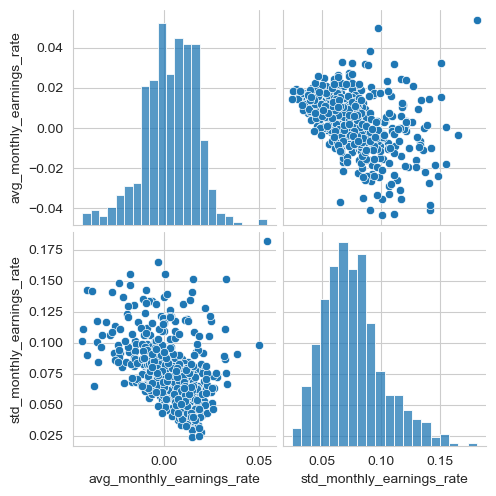

In [95]:
sns.pairplot(data7)

In [96]:
df1 = pd.DataFrame(data7.corr())
df1

,avg_monthly_earnings_rate,std_monthly_earnings_rate
avg_monthly_earnings_rate,1.000000,-0.384874
std_monthly_earnings_rate,-0.384874,1.000000


In [97]:
train_data = data7

# k-means

## sklearn的k-means

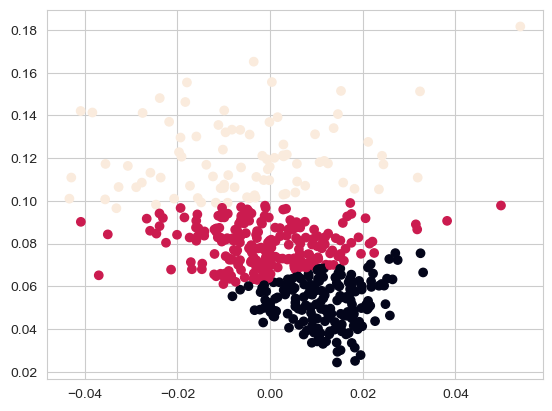

In [98]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

y_pred = KMeans(n_clusters=3, random_state=9).fit_predict(train_data)
y_pred
plt.scatter(train_data.iloc[:, 0], train_data.iloc[:, 1], c=y_pred)
plt.show()

## sklearn的k-means

In [99]:
import matplotlib.pyplot as plt

from sklearn_extra.cluster import KMedoids

y_pred = KMeans(n_clusters=3, random_state=9).fit_predict(train_data)
y_pred
plt.scatter(train_data.iloc[:, 0], train_data.iloc[:, 1], c=y_pred)
plt.show()

ModuleNotFoundError: No module named 'sklearn_extra'